# DBSCAN Clustering on Energy Dataset (Optimized for Large Datasets)
This notebook performs DBSCAN clustering using PCA reduction and memory-optimized preprocessing.


In [1]:
import pandas as pd
import gc
from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler
from rice_ml.unsupervised_learning.dbscan import (
    load_dataset,
    select_numeric,
    scale_features,
    compute_k_distance,
    run_dbscan,
    add_cluster_labels,
    plot_k_distance,
    plot_clusters,
)

In [2]:
energy_df = load_dataset(("../../../datasets/energy.csv"))
energy_df.head()


,Unnamed: 0,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,4,2001,1,AK,Total Electric Power Industry,Wind,87.0


## Why DBSCAN?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is well-suited for this dataset because:

- It does **not require specifying the number of clusters**
- It can identify **arbitrarily shaped clusters**
- It explicitly labels **outliers and noise points**
- It is effective for detecting **rare or anomalous behavior**

Unlike K-Means, DBSCAN does not assume spherical clusters or equal variance, making it appropriate for exploratory analysis of complex energy data.


# Select Numeric Features
DBSCAN is a distance-based clustering algorithm, so only numeric columns can be used.

In [3]:
# We filter the dataset to keep only numeric columns.
numeric_df = select_numeric(energy_df)
numeric_df.head()


,Unnamed: 0,YEAR,MONTH,GENERATION (Megawatthours)
0,0,2001,1,46903.0
1,1,2001,1,71085.0
2,2,2001,1,367521.0
3,3,2001,1,104549.0
4,4,2001,1,87.0


# Subsample the Dataset to Prevent Memory Errors
Large datasets can cause PCA and DBSCAN to crash due to RAM usage.

In [4]:
# We use a 50,000-row subsample for efficiency.
sampled_df = numeric_df.sample(n=50000, random_state=42)
sampled_df.head()

,Unnamed: 0,YEAR,MONTH,GENERATION (Megawatthours)
145911,61976,2007,11,7499.00
484438,23672,2021,12,0.00
6201,6201,2001,4,306704.00
220057,26073,2011,2,4250.41
383802,24126,2017,12,109212.00


# Scale Features
Standardization brings all variables to the same scale, which is required for PCA and DBSCAN.

In [5]:
scaled_data = scale_features(sampled_df)
scaled_data[:5]


array([[ 3.27867284, -0.75459099,  1.32729784, -0.13255459],
       [ 0.41624852,  1.51232328,  1.61680377, -0.13327771],
       [-0.88934399, -1.72612567, -0.69924368, -0.10370246],
       [ 0.59567314, -0.1069012 , -1.27825554, -0.13286785],
       [ 0.45017554,  0.86463349,  1.61680377, -0.12274647]])

In [6]:
numeric_df = None
gc.collect()

40

# Apply Incremental PCA (Memory Efficient)
IncrementalPCA processes data in small batches, avoiding MemoryError issues.

In [7]:
ipca = IncrementalPCA(n_components=2, batch_size=5000)
reduced = ipca.fit_transform(scaled_data)


pca_df = pd.DataFrame(reduced, columns=["PC1", "PC2"])
pca_df.head()

,PC1,PC2
0,3.365598,0.322760
1,0.566010,1.816202
2,-0.285133,-1.383437
3,-0.277652,-0.577089
4,0.867520,1.401325


In [8]:
scaled_data = None
gc.collect()

0

# Scale PCA Components
DBSCAN performs best when PCA outputs are standardized.

In [9]:
scaler_pca = StandardScaler()
pca_scaled = scaler_pca.fit_transform(reduced)

# Compute k-Distance Plot
The k-distance plot helps select an appropriate eps value by highlighting density transitions.

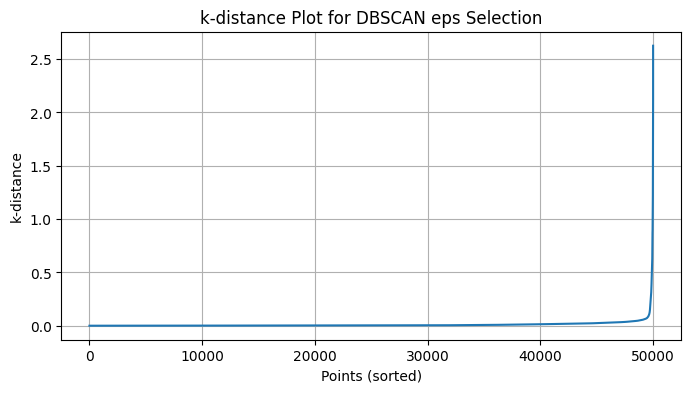

In [10]:
k_distances = compute_k_distance(pca_scaled, k=5)
plot_k_distance(k_distances)


The k-distance plot shows that:

- Most observations are extremely tightly packed in PCA space
- A small fraction of points have significantly larger k-distances

This characteristic “elbow” shape indicates:

- One dominant dense region
- A small number of sparse points that may represent outliers or secondary regimes

This behavior suggests that DBSCAN is more appropriate for **outlier detection**
and **density separation** than for discovering many equally sized clusters.


# Testing eps and min_samples for DBSCAN
Based on tuning experiments

In [11]:
# Adjust these values after inspecting the k-distance ploteps_value = 1.5
eps_value = 0.1
min_samples_value = 5


# Run DBSCAN on PCA-Transformed Data
DBSCAN assigns each point to a dense region (cluster) or labels it as noise (-1).

In [12]:
labels = run_dbscan(pca_scaled, eps=eps_value, min_samples=min_samples_value)
labels[:20]

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

This shows that DBSCAN does not fall into a single cluster, at least two clusters are shown.

In [13]:
len(set(labels))


12

# Add Cluster Labels to DataFrame
We combine the PCA-transformed data with the DBSCAN-generated cluster labels.

In [14]:
clustered_df = add_cluster_labels(pca_df, labels)

clustered_df.head()

,PC1,PC2,cluster
0,3.365598,0.322760,0
1,0.566010,1.816202,1
2,-0.285133,-1.383437,1
3,-0.277652,-0.577089,1
4,0.867520,1.401325,1


# Interpretation:
- PC1 = dominant direction of variance
- PC2 = secondary variance direction

The point in cluster 0 has a much higher PC1 value.

Cluster 0 is far from the center of the main data mass.

# This supports the idea that:

- Cluster 0 represents unusual energy behavior
- Cluster 1 represents the dominant operating regime of the energy system

# Visualize Clusters in PCA Space
This scatterplot reveals how DBSCAN separated the dense regions of the dataset.

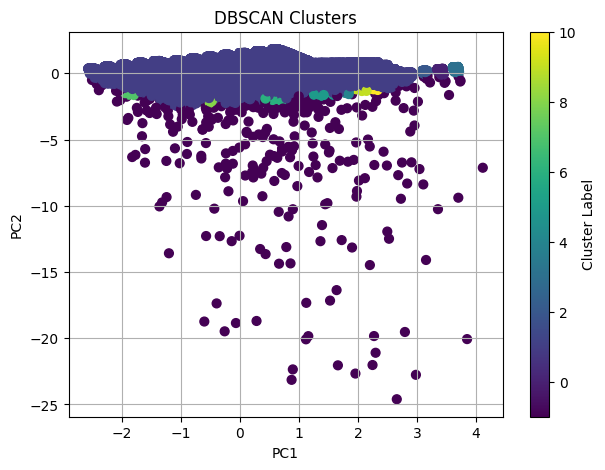

In [15]:
plot_clusters(pca_df, labels, "PC1", "PC2")

# What this plot represents

- Each point is an observation from the energy dataset.
- The x-axis (PC1) and y-axis (PC2) are the first two principal components, capturing the largest variance in the data.
- Colors represent DBSCAN cluster labels.
- Dark purple points correspond to the dominant cluster.
- Lighter/greener/yellow points correspond to smaller clusters or edge cases.

In [16]:
clustered_df["cluster"].value_counts()

cluster
 1     49121
-1       308
 2       177
 3       176
 0       165
 6        14
 5        11
 9         7
 7         6
 4         6
 8         5
 10        4
Name: count, dtype: int64

# Testing eps for reducing number of clusters

In [17]:
eps_values = [0.12, 0.15, 0.18, 0.2]


In [18]:
for eps in eps_values:
    labels_test = run_dbscan(pca_scaled, eps=eps, min_samples=10)
    print(eps, len(set(labels_test)))


0.12 6
0.15 2
0.18 2
0.2 2


eps = 0.18 provides stable clustering (2 clusters)

# Why eps = 0.18 is a good choice

- It lies at the start of the stable region
- Preserves meaningful separation
- Avoids unnecessary merging that may happen at larger eps
- Matches the k-distance plot behavior

# Run and plot final eps 

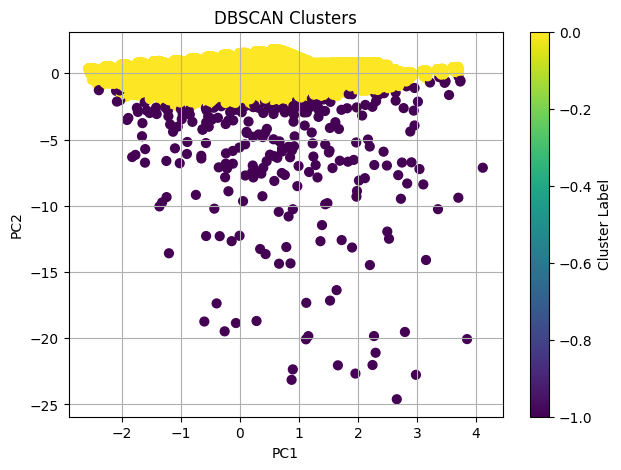

In [19]:
final_eps = 0.18
labels_final = run_dbscan(pca_scaled, eps=final_eps, min_samples=10)
plot_clusters(pca_df, labels_final, "PC1", "PC2")


## Conclusion

DBSCAN clustering was applied to the energy dataset using PCA-based dimensionality reduction and memory-efficient preprocessing. Initial clustering attempts revealed a single dominant dense region, indicating limited density variation in the raw high-dimensional feature space.

After applying Incremental PCA and tuning the `eps` parameter using the k-distance plot, DBSCAN identified a **stable two-cluster structure**, along with a small number of noise points. The dominant cluster represents typical operating behavior, while the secondary cluster and noise points capture **atypical or extreme energy patterns**.

This analysis demonstrates that:

- PCA is essential for revealing meaningful density structure in large numeric datasets
- DBSCAN is best interpreted as a **density and outlier detection method**
- Results are qualitative and exploratory rather than predictive

Overall, DBSCAN provides valuable insight into non-linear structure and anomalous behavior once dimensionality and scale are properly controlled.
